## Implementing the XOR gate through evolutionary algorithms ##

The aim of this project is to implement a simple logic gate, the XOR gate, on a basic neural network, and to do so by means of evolutionary algorithms.
This work is mostly propaedeutic for the following project, which would be to use evolutionary algorithm to study the evolution of the basic computational cell, in order to verify if the neuron (i.e. a cell dedicated to computation, characterized by a threshold mechanic and a polarity) is the only possible solution achievable through evolution or if, instead, there are other possibility which haven't been explored. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

import network as n

# Set the seed for random generations
np.random.seed(12345)

First of all, I'll briefly explain how the code is structured. It is divided between two files:
- network.py: contains
    - class Network: implements the network structure, with its basic attributes and methods.
    - function evolution(par): it's the evolutionary algorithm that searches the parameters space for the best network which implements the target gate.
- xor.ipynb (this file): here the simulation parameters are defined, the code is executed and the resulting data is briefly analyzed. 

In [ ]:
# Define the set of parameters
par = {'Sk_range': [1,2,3,4,5],                  # define the possible value for S.
       'Theta_range': [-1,+1],                   # define the possible value for Theta.
       'J_range': [-1,+1],                       # define the possible value for J.
       'input_set':[[0,0],[0,1],[1,0],[1,1]],    # Set of inputs.
       'target_set': [0.0,1.0,1.0,0.0],          # set of outputs for the XOR gate .
       'mutation_ratio': 0.8,                    # set the ratio of mutated solutions over the whole number of individuals that have to be generate after a selection. Who is not mutated is random 
       'S_mutation_radius': 1,                   # module of the mutation applied on S (when a mutation is applied).
       'Theta_mutation_radius': 0.1,             # standard deviation of the normal distribution used to sample the mutation value for Theta.
       'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
       'N_sol': 200,                             # Set the number of solutions.
       'n_iter': 1000}                           # Number of iterations of the algorithm.                  

Now I'll present the Network class: this class is used to construct a basic neural network object, which in this project acts as the individual of the population that undergoes evolution. Each Network object is charcterized by some attributes:
- 2 input neurons, 1 output neurons.
- S intra neurons, organized in a single layer.
- A array Theta, containing the threshold values of each neuron.
- A weight matrix J. The element $J_{ij}$ refers to the link from neuron j to neuron i.
- A connectivity matrix C, which expresses the presence or absence of a link between two given neurons. It uses the same indexes convention as J.
- A fitness value.
- An activation function, which is common to every Network object.

Note that both matrices J and C are symmetric, but since the links in the network are always forward-directioned, I actually consider just the lower triangle in both matrices. In the evolution algorithm I update also the higher triangle elements, but only for simplicity, since they're never considered. The algorithm would surely benefit in terms of performances if the two matrices would be kept always symmetric.

Next, I'll briefly explain the method Network.generate(par), which is used to generate a random Network object: this method randomly sets all the parameters mentioned above (except for the activation function, which is fixed). All the parameters are uniformly sampled from the respective range and the neurons are all set to zero. Moreover, the fitness of the network is computed, using the apposite method. 

The search algorithm selects the individuals based on their fitness value, which is defined as such:
$$
f(\Omega) = \frac{1}{N_I N}\sum^N_{k}\left[ \sum^{N_I}_I\alpha\left(O^T - O_k\right)_I^2 + S\left(\frac{\sum_{i,j} C_{i,j}}{2}\right)_I\right]
$$
where $\Omega$ is the set of the individuals, $N_I$ is the number of possible inputs to the network, in this case 4, S is the number of intra neurons, N the number of individuals. $O^T$ is the target output, while $O_k$ is the actual output, given input I. Finally, $\alpha$ is a factor used to weight the first term of the fitness function and in this case was set to 20.

In [ ]:
solutions, Fmean_values= n.evolution(par,verb=2)

Iteration #0...
# of childs: 72
Iteration #10...
# of childs: 64
Iteration #20...
# of childs: 68
Iteration #30...
# of childs: 18
Iteration #40...
# of childs: 16
Iteration #50...
# of childs: 33
Iteration #60...
# of childs: 36
Iteration #70...
# of childs: 12
Iteration #80...
# of childs: 32
Iteration #90...
# of childs: 16
Iteration #100...
# of childs: 20
Iteration #110...
# of childs: 23
Iteration #120...
# of childs: 28
Iteration #130...
# of childs: 28
Iteration #140...
# of childs: 37
Iteration #150...
# of childs: 21
Iteration #160...
# of childs: 16
Iteration #170...
# of childs: 26
Iteration #180...
# of childs: 16
Iteration #190...
# of childs: 7
Iteration #200...
# of childs: 21
Iteration #210...
# of childs: 24
Iteration #220...
# of childs: 15
Iteration #230...
# of childs: 22
Iteration #240...
# of childs: 13
Iteration #250...
# of childs: 18
Iteration #260...
# of childs: 12
Iteration #270...
# of childs: 6
Iteration #280...
# of childs: 5
Iteration #290...
# of child

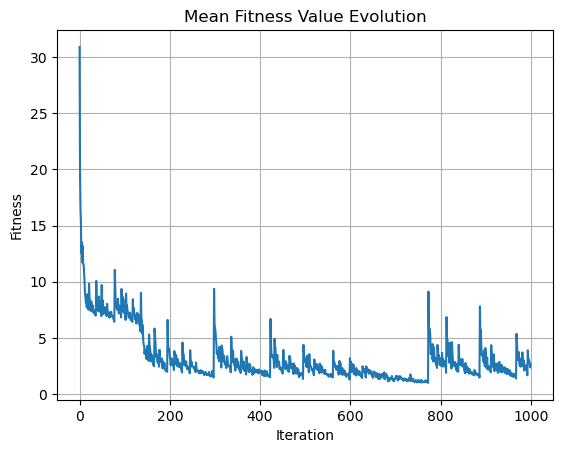

In [8]:
plt.plot(Fmean_values)
plt.title('Mean Fitness Value Evolution')
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.grid(True)
plt.show()

In [5]:
print(f'Final mean fitness: {Fmean_values[-1]}')
for i,sol in enumerate(solutions):
    print(f'Solution #{i}...')
    print(f'Fitness: {sol.fitness}')
    print(f'S: {sol.S}')
    print(f'Theta: {sol.Theta}')
    for input in par['input_set']:
        print(f'{input} Output: {sol.ff(input)}')

Final mean fitness: 1.9625
Solution #0...
Fitness: 1.0
S: 1
Theta: [-0.37113483 -0.19542772 -0.63879447 -0.76643195]
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #1...
Fitness: 1.5
S: 1
Theta: [-0.85286585 -0.70884362 -0.42511241 -0.90667291]
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #2...
Fitness: 0.5
S: 1
Theta: [-0.64435584  0.05668843 -0.50166802 -0.48759272]
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #3...
Fitness: 0.5
S: 1
Theta: [ 0.28095254 -0.27140581 -0.34428203 -0.68432163]
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #4...
Fitness: 20.0
S: 2
Theta: [-0.67848416  0.22705132  0.22160603  0.2389104  -0.19031761]
[0, 0] Output: 1.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 1.0
Solution #5...
Fitness: 1.0
S: 1
Theta: [-0.60962534  0.13665608 -0.34418582 -0.53076547]
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1